NAME: KAVISH PARASWAR

PRN:12311694

ROLL NO: 2

CSE(AI) B

Assignment No. 5 :Learn Decision trees for regression and classification problem

a. Split the data set into training and test sets.

b. Build the decision tree

c. Check model performances on training and test data sets.

d. Apply cost complexity pruning to overcome overfitting problem

e. Apply Random Forest algorithm to overcome overfitting problem.

f. Apply Ada-boost ensemble method on Decision stumps.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

# Load Dataset
df = pd.read_csv("car_evaluation.csv")

In [ ]:
df.columns = [
    "buying", "maint", "doors", "persons",
    "lug_boot", "safety", "class"
]

# Encode categorical values
le = LabelEncoder()
for col in df.columns:
    df[col] = le.fit_transform(df[col])

# Split features and target
X = df.drop("class", axis=1)
y = df["class"]

In [ ]:
# (a) Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# (b) Build Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
# (c) Model Performance
train_acc = dt_model.score(X_train, y_train)
test_acc = dt_model.score(X_test, y_test)

print("Decision Tree Training Accuracy:", train_acc)
print("Decision Tree Testing Accuracy:", test_acc)
print("\nClassification Report:\n", classification_report(y_test, dt_model.predict(X_test)))

Decision Tree Training Accuracy: 1.0
Decision Tree Testing Accuracy: 0.9710982658959537

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.95      0.95        77
           1       0.75      0.80      0.77        15
           2       1.00      1.00      1.00       237
           3       0.83      0.88      0.86        17

    accuracy                           0.97       346
   macro avg       0.89      0.91      0.90       346
weighted avg       0.97      0.97      0.97       346



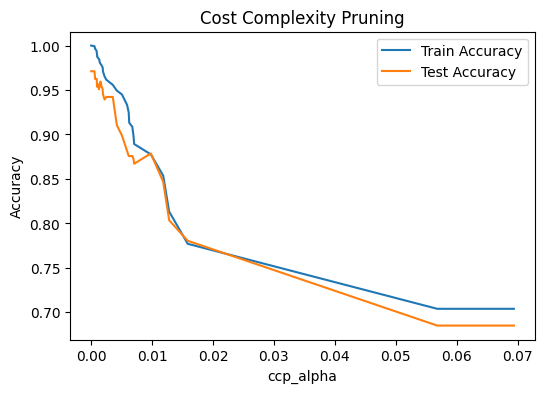

In [ ]:
# (d) Cost Complexity Pruning
path = dt_model.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

dt_models = []

for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    model.fit(X_train, y_train)
    dt_models.append(model)

train_scores = [model.score(X_train, y_train) for model in dt_models]
test_scores = [model.score(X_test, y_test) for model in dt_models]

plt.figure(figsize=(6,4))
plt.plot(ccp_alphas, train_scores, label="Train Accuracy")
plt.plot(ccp_alphas, test_scores, label="Test Accuracy")
plt.xlabel("ccp_alpha")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Cost Complexity Pruning")
plt.show()


In [ ]:
# Select best pruned model
best_alpha = ccp_alphas[np.argmax(test_scores)]
pruned_model = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha)
pruned_model.fit(X_train, y_train)

print("Pruned Tree Test Accuracy:", pruned_model.score(X_test, y_test))

Pruned Tree Test Accuracy: 0.9710982658959537


In [ ]:
# (e) Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("Random Forest Test Accuracy:", rf_model.score(X_test, y_test))

Random Forest Test Accuracy: 0.9624277456647399


In [ ]:
# (f) AdaBoost with Decision Stumps
stump = DecisionTreeClassifier(max_depth=1)
ada_model = AdaBoostClassifier(
    estimator=stump, # Changed base_estimator to estimator
    n_estimators=100,
    random_state=42
)

ada_model.fit(X_train, y_train)

print("AdaBoost Test Accuracy:", ada_model.score(X_test, y_test))

AdaBoost Test Accuracy: 0.8179190751445087
